In [1]:
# Cell 0: ติดตั้ง dependencies (รันครั้งแรกครั้งเดียว)
import subprocess, sys

packages = [
    'numpy', 'pandas', 'matplotlib', 'seaborn',
    'scikit-learn', 'scipy', 'joblib',
    'torch', 'fastdtw', 'tqdm',
    'mediapipe', 'opencv-python',
    'yt-dlp',
]

for pkg in packages:
    print(f'Installing {pkg}...', end=' ')
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q', '--break-system-packages'],
        capture_output=True, text=True
    )
    print('✅' if result.returncode == 0 else f'❌ {result.stderr[:80]}')

print('\n✅ ติดตั้งครบแล้ว — รัน Cell ถัดไปได้เลย')

Installing numpy... ✅
Installing pandas... ✅
Installing matplotlib... ✅
Installing seaborn... ✅
Installing scikit-learn... ✅
Installing scipy... ✅
Installing joblib... ✅
Installing torch... ✅
Installing fastdtw... ✅
Installing tqdm... ✅
Installing mediapipe... ✅
Installing opencv-python... ✅
Installing yt-dlp... ✅

✅ ติดตั้งครบแล้ว — รัน Cell ถัดไปได้เลย


# 🕺 K-Pop Dance Pose Classification — UP (Karina)
## EDA · Feature Engineering · Pose Clustering · Anomaly Detection

**เป้าหมาย:** สร้างโมเดลตรวจจับว่าท่าเต้นของผู้ใช้ผ่านหรือไม่ผ่าน (PASS/FAIL)  
โดยเรียนรู้จาก reference video (ท่าที่ถูกต้อง) อย่างเดียว



**ทำไม Anomaly Detection?**  
- ไม่ต้องการ FAIL data เลย (เรียนรู้จาก PASS อย่างเดียว)  
- กำหนดแค่ threshold เดียว (ไม่ใช่ 55 if-else)  
- โมเดลเรียนรู้ความสัมพันธ์ระหว่าง features ทั้งหมดเอง

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.ndimage import gaussian_filter1d
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='darkgrid')
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Dataset Overview

In [3]:
# 1. Dataset Overview — ทำความรู้จักข้อมูลจริงๆ
import cv2, os

data       = np.load('results/pose_cache/reference.npz', allow_pickle=True)
keypoints  = data['keypoints']    # (n_frames, 13, 2)
visibility = data['visibility']   # (n_frames, 13)
timestamps = data['timestamps']   # (n_frames,)
fps        = float(data['fps'])
sample_fps = float(data['sample_fps'])

KEYPOINT_NAMES = [
    'Nose', 'L.Shoulder', 'R.Shoulder', 'L.Elbow', 'R.Elbow',
    'L.Wrist', 'R.Wrist', 'L.Hip', 'R.Hip', 'L.Knee',
    'R.Knee', 'L.Ankle', 'R.Ankle'
]

n_frames, n_kp, _ = keypoints.shape
duration = n_frames / sample_fps

# --- อ่าน metadata วิดีโอจริงๆ ---
vid_dir  = 'results/reference_videos'
vid_files = [f for f in os.listdir(vid_dir) if f.endswith('.mp4')] if os.path.isdir(vid_dir) else []

print('=' * 60)
print('  VIDEO FILES')
print('=' * 60)
for vf in sorted(vid_files):
    cap = cv2.VideoCapture(os.path.join(vid_dir, vf))
    v_fps    = cap.get(cv2.CAP_PROP_FPS)
    v_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    v_w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    v_h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    v_dur    = v_frames / v_fps if v_fps > 0 else 0
    cap.release()
    role = "PASS (Reference)"   # videos ใน reference_videos คือ reference ทั้งหมด
    print(f"  {vf[:55]}")
    print(f"    Role       : {role}")
    print(f"    Resolution : {v_w} x {v_h}  ({'portrait' if v_h > v_w else 'landscape'})")
    print(f"    Native FPS : {v_fps:.1f}")
    print(f"    Duration   : {v_dur:.1f}s  ({v_dur/60:.1f} min)")
    print(f"    Frames     : {v_frames:,}")
    print()

print('=' * 60)
print('  KEYPOINT DATA (after sampling)')
print('=' * 60)
print(f"  Sample FPS      : {sample_fps} fps  (down-sampled จาก {fps:.0f} fps)")
print(f"  Total frames    : {n_frames:,}")
print(f"  Duration        : {duration:.1f}s  ({duration/60:.1f} min)")
print(f"  Array shape     : {keypoints.shape}  → (frames, joints, xy)")
print(f"  Joints tracked  : {n_kp}  (จาก MediaPipe 33 จุด เลือก upper/lower body)")
print(f"  Values per frame: {n_kp * 2}  (13 joints × x,y)")
print(f"  Coordinate range: x ∈ [0,1], y ∈ [0,1]  (normalized by video size)")
print(f"  Total data pts  : {n_frames * n_kp * 2:,}")
print()
print(f"  Memory          : {keypoints.nbytes / 1024:.1f} KB")


  VIDEO FILES
  [Mirrored] KARINA(카리나) - UP(업) 1인 커버댄스 ㅣ1인안무 거울모드.mp4
    Role       : PASS (Reference)
    Resolution : 1920 x 1080  (landscape)
    Native FPS : 30.0
    Duration   : 58.1s  (1.0 min)
    Frames     : 1,740

  KEYPOINT DATA (after sampling)
  Sample FPS      : 10.0 fps  (down-sampled จาก 30 fps)
  Total frames    : 579
  Duration        : 57.9s  (1.0 min)
  Array shape     : (579, 13, 2)  → (frames, joints, xy)
  Joints tracked  : 13  (จาก MediaPipe 33 จุด เลือก upper/lower body)
  Values per frame: 26  (13 joints × x,y)
  Coordinate range: x ∈ [0,1], y ∈ [0,1]  (normalized by video size)
  Total data pts  : 15,054

  Memory          : 58.8 KB


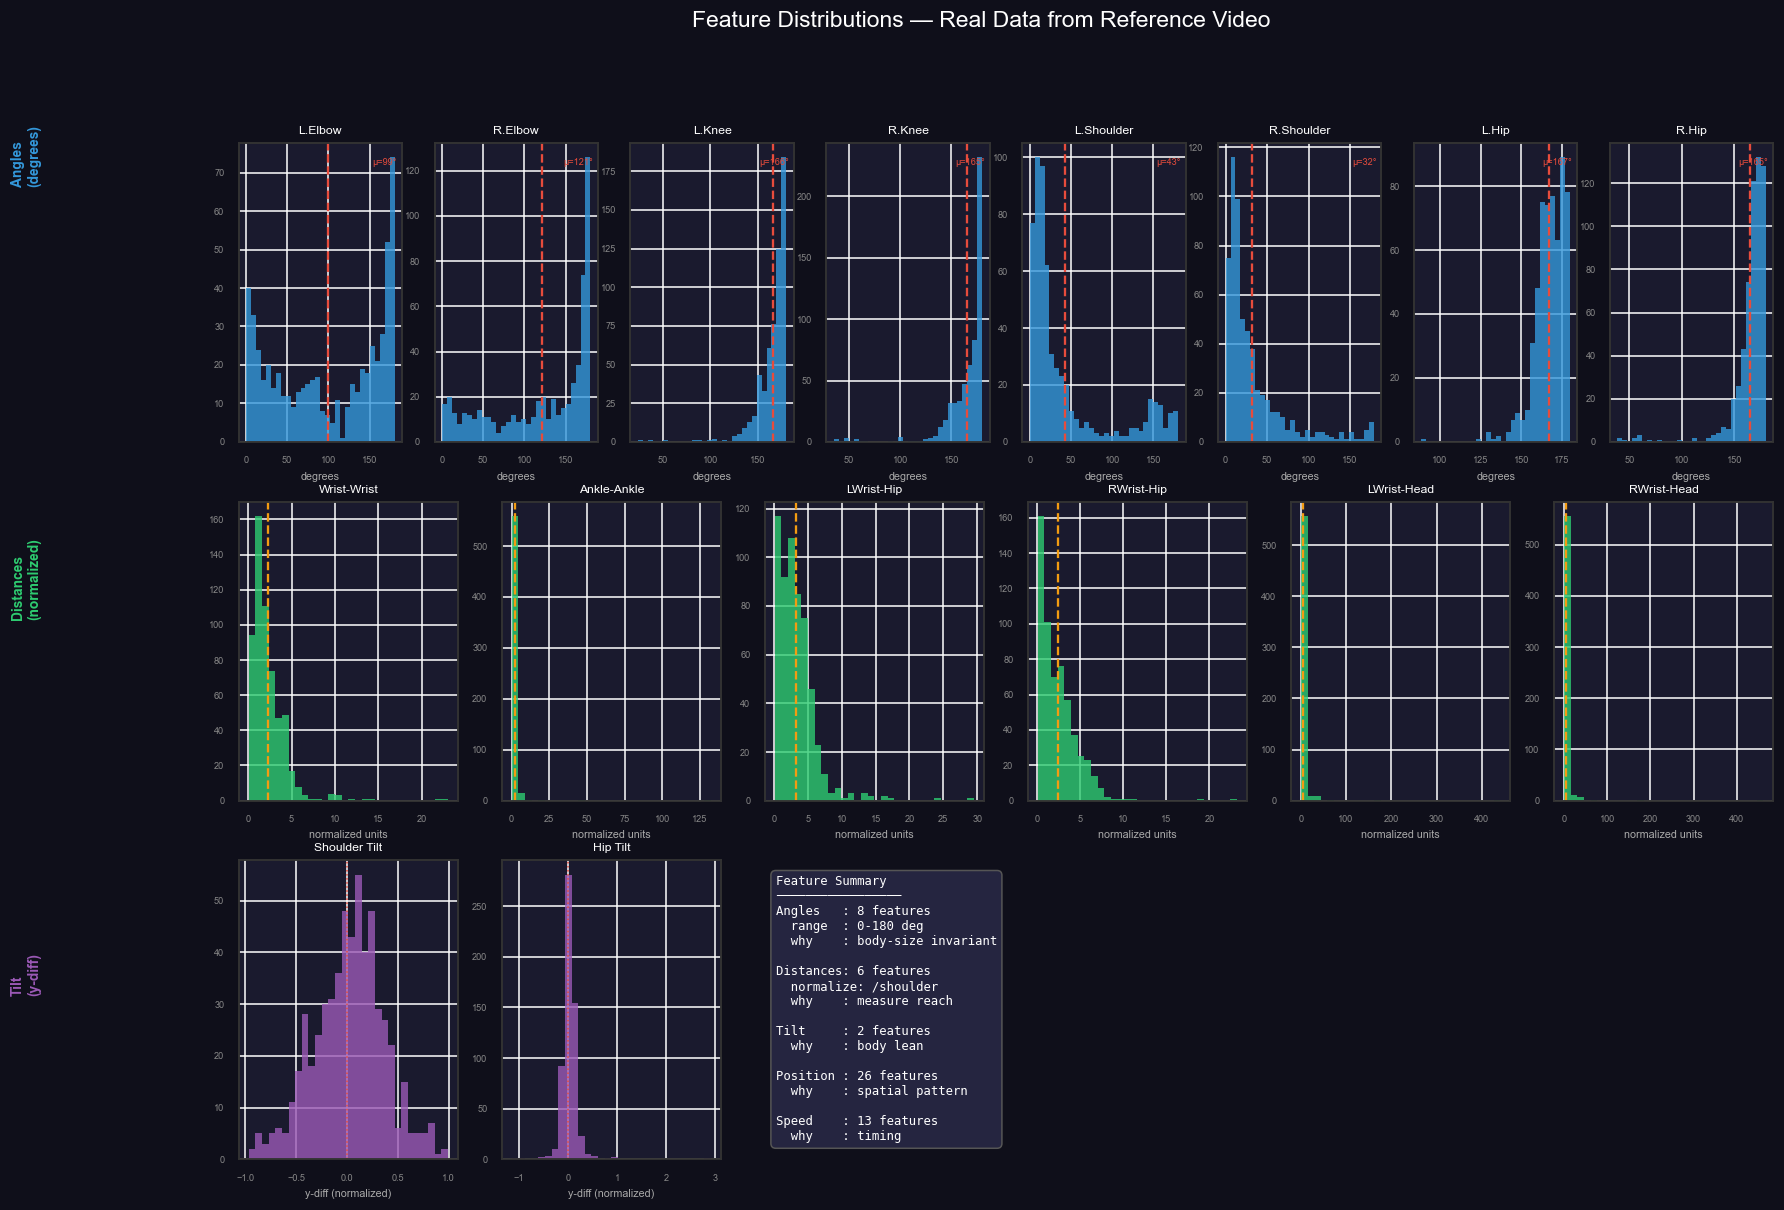

✅ Saved: results/feature_distributions.png

Key observations:
  • Angles range from 0° to 180° across all frames
  • Most-variable joint: L.Elbow  (std=63.7°)
  • Least-variable joint: L.Hip  (std=9.5°)
  • Hand spread (Wrist-Wrist) avg: 2.33 shoulder-widths
  • Foot spread (Ankle-Ankle) avg: 1.92 shoulder-widths


In [4]:
# 1.1 ทำไมถึงเลือก Feature แต่ละกลุ่ม — Feature Rationale

# --- คำนวณ features จริงๆ แล้ว plot distribution ---
from sklearn.preprocessing import StandardScaler

def compute_angle(a, b, c):
    ba = a- b; bc = c - b
    norm = np.linalg.norm(ba, axis=-1) * np.linalg.norm(bc, axis=-1) + 1e-8
    return np.degrees(np.arccos(np.clip(np.einsum("...i,...i", ba, bc) / norm, -1, 1)))

def extract_features_explained(kps):
    hip_c  = (kps[:, 7] + kps[:, 8]) / 2
    shld_w = np.linalg.norm(kps[:, 1] - kps[:, 2], axis=1, keepdims=True) + 1e-8
    kn     = (kps - hip_c[:, None, :]) / shld_w[:, None, :]   # normalize

    angles = np.column_stack([
        compute_angle(kps[:,1], kps[:,3], kps[:,5]),   # ข้อศอกซ้าย
        compute_angle(kps[:,2], kps[:,4], kps[:,6]),   # ข้อศอกขวา
        compute_angle(kps[:,7], kps[:,9], kps[:,11]),  # หัวเข่าซ้าย
        compute_angle(kps[:,8], kps[:,10],kps[:,12]),  # หัวเข่าขวา
        compute_angle(kps[:,3], kps[:,1], kps[:,7]),   # ไหล่ซ้าย
        compute_angle(kps[:,4], kps[:,2], kps[:,8]),   # ไหล่ขวา
        compute_angle(kps[:,1], kps[:,7], kps[:,9]),   # สะโพกซ้าย
        compute_angle(kps[:,2], kps[:,8], kps[:,10]),  # สะโพกขวา
    ])

    dists = np.hstack([
        np.linalg.norm(kn[:,5]  - kn[:,6],  axis=1, keepdims=True),  # มือ↔มือ
        np.linalg.norm(kn[:,11] - kn[:,12], axis=1, keepdims=True),  # เท้า↔เท้า
        np.linalg.norm(kn[:,5]  - kn[:,7],  axis=1, keepdims=True),  # มือL↔สะโพกL
        np.linalg.norm(kn[:,6]  - kn[:,8],  axis=1, keepdims=True),  # มือR↔สะโพกR
        np.linalg.norm(kn[:,5]  - kn[:,0],  axis=1, keepdims=True),  # มือL↔หัว
        np.linalg.norm(kn[:,6]  - kn[:,0],  axis=1, keepdims=True),  # มือR↔หัว
    ])

    tilt = np.hstack([
        (kn[:,1,1] - kn[:,2,1]).reshape(-1,1),   # ระดับไหล่
        (kn[:,7,1] - kn[:,8,1]).reshape(-1,1),   # ระดับสะโพก
    ])

    return angles, dists, tilt, kn

angles, dists, tilt, kn = extract_features_explained(keypoints)

angle_names = ["L.Elbow", "R.Elbow", "L.Knee", "R.Knee",
               "L.Shoulder", "R.Shoulder", "L.Hip", "R.Hip"]
dist_names  = ["Wrist-Wrist", "Ankle-Ankle", "LWrist-Hip", "RWrist-Hip",
               "LWrist-Head", "RWrist-Head"]

fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("#0f0f1a")
fig.suptitle("Feature Distributions — Real Data from Reference Video", 
             fontsize=15, color="white", y=0.98)

# Row 1: Angles
axes_ang = [fig.add_subplot(3, 8, i+1) for i in range(8)]
for ax, vals, name in zip(axes_ang, angles.T, angle_names):
    ax.hist(vals, bins=30, color="#3498db", alpha=0.8, edgecolor="none")
    ax.set_title(name, fontsize=8, color="white")
    ax.set_xlabel("degrees", fontsize=7, color="#aaa")
    ax.tick_params(colors="#888", labelsize=6)
    ax.set_facecolor("#1a1a2e")
    for sp in ax.spines.values(): sp.set_color("#333")
    ax.axvline(vals.mean(), color="#e74c3c", lw=1.5, linestyle="--")
    ax.text(0.97, 0.95, f"μ={vals.mean():.0f}°", transform=ax.transAxes,
            ha="right", va="top", fontsize=6, color="#e74c3c")

# Row 2: Distances
axes_dist = [fig.add_subplot(3, 6, 7+i) for i in range(6)]
for ax, vals, name in zip(axes_dist, dists.T, dist_names):
    ax.hist(vals, bins=30, color="#2ecc71", alpha=0.8, edgecolor="none")
    ax.set_title(name, fontsize=8, color="white")
    ax.set_xlabel("normalized units", fontsize=7, color="#aaa")
    ax.tick_params(colors="#888", labelsize=6)
    ax.set_facecolor("#1a1a2e")
    for sp in ax.spines.values(): sp.set_color("#333")
    ax.axvline(vals.mean(), color="#f39c12", lw=1.5, linestyle="--")

# Row 3: Tilt + Summary box
ax_tilt_l = fig.add_subplot(3, 6, 13)
ax_tilt_r = fig.add_subplot(3, 6, 14)
for ax, vals, name in zip([ax_tilt_l, ax_tilt_r], tilt.T, ["Shoulder Tilt", "Hip Tilt"]):
    ax.hist(vals, bins=30, color="#9b59b6", alpha=0.8, edgecolor="none")
    ax.set_title(name, fontsize=8, color="white")
    ax.set_xlabel("y-diff (normalized)", fontsize=7, color="#aaa")
    ax.tick_params(colors="#888", labelsize=6)
    ax.set_facecolor("#1a1a2e")
    for sp in ax.spines.values(): sp.set_color("#333")
    ax.axvline(0, color="#e74c3c", lw=1, linestyle=":")

# Summary text box
ax_txt = fig.add_subplot(3, 6, 15)
ax_txt.axis("off")
ax_txt.set_facecolor("#1a1a2e")
summary = (
    "Feature Summary\n"
    "─────────────────\n"
    f"Angles   : 8 features\n"
    f"  range  : 0-180 deg\n"
    f"  why    : body-size invariant\n\n"
    f"Distances: 6 features\n"
    f"  normalize: /shoulder\n"
    f"  why    : measure reach\n\n"
    f"Tilt     : 2 features\n"
    f"  why    : body lean\n\n"
    f"Position : 26 features\n"
    f"  why    : spatial pattern\n\n"
    f"Speed    : 13 features\n"
    f"  why    : timing\n\n"
    f"Accel    : 13 features\n"
    f"  why    : rhythm/impulse"
)
ax_txt.text(0.05, 0.95, summary, transform=ax_txt.transAxes,
    va="top", ha="left", fontsize=8, color="white",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#252540", edgecolor="#555"))

# Row labels
fig.text(0.01, 0.87, "Angles\n(degrees)", fontsize=9, color="#3498db",
         va="center", rotation=90, fontweight="bold")
fig.text(0.01, 0.55, "Distances\n(normalized)", fontsize=9, color="#2ecc71",
         va="center", rotation=90, fontweight="bold")
fig.text(0.01, 0.25, "Tilt\n(y-diff)", fontsize=9, color="#9b59b6",
         va="center", rotation=90, fontweight="bold")

plt.tight_layout(rect=[0.03, 0, 1, 0.97])
plt.savefig("results/feature_distributions.png", dpi=120, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved: results/feature_distributions.png")
print()
print("Key observations:")
print(f"  • Angles range from {angles.min():.0f}° to {angles.max():.0f}° across all frames")
print(f"  • Most-variable joint: {angle_names[angles.std(axis=0).argmax()]}  (std={angles.std(axis=0).max():.1f}°)")
print(f"  • Least-variable joint: {angle_names[angles.std(axis=0).argmin()]}  (std={angles.std(axis=0).min():.1f}°)")
print(f"  • Hand spread (Wrist-Wrist) avg: {dists[:,0].mean():.2f} shoulder-widths")
print(f"  • Foot spread (Ankle-Ankle) avg: {dists[:,1].mean():.2f} shoulder-widths")


## 2. EDA — Data Quality Problems

> MediaPipe ไม่ได้ detect ได้ perfect ทุกเฟรม — ต้องดูก่อนว่ามีปัญหาอะไรบ้างใน dataset

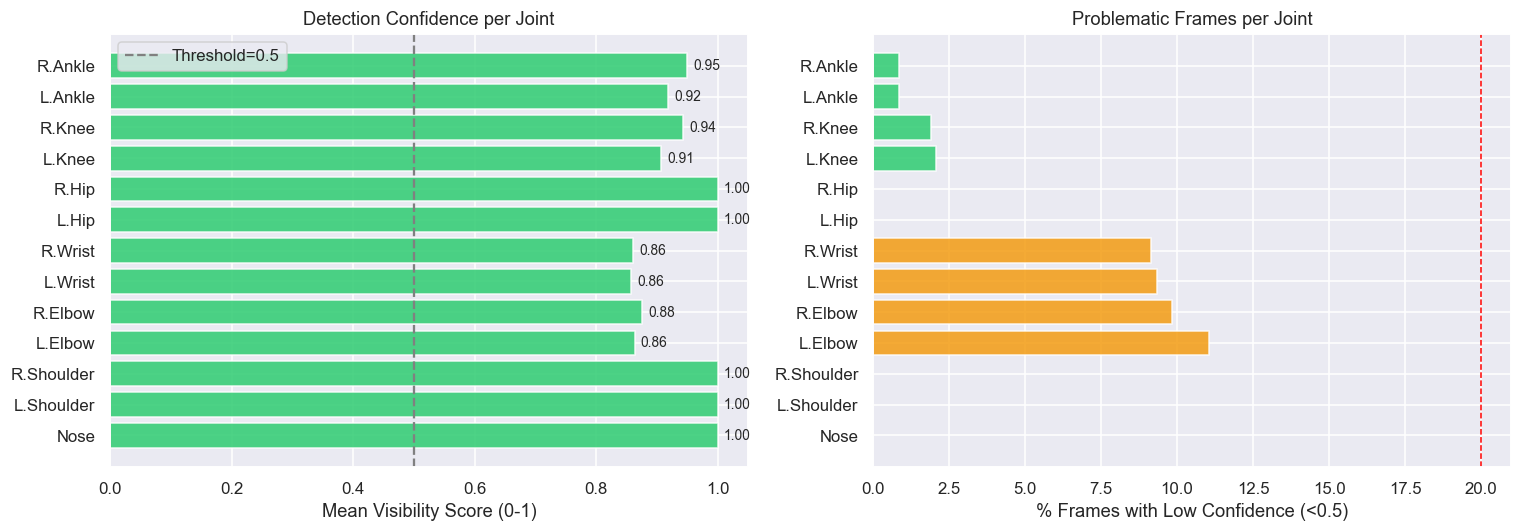

Overall quality: 77.9% frames fully visible


In [5]:
# 2.1 Visibility (Confidence) per keypoint
VIS_THRESH = 0.5
low_vis_mask = visibility < VIS_THRESH
mean_vis  = visibility.mean(axis=0)
low_count = low_vis_mask.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if v < VIS_THRESH else '#2ecc71' for v in mean_vis]
bars = axes[0].barh(KEYPOINT_NAMES, mean_vis, color=colors, alpha=0.85)
axes[0].axvline(VIS_THRESH, color='gray', linestyle='--', label=f'Threshold={VIS_THRESH}')
axes[0].set_xlabel('Mean Visibility Score (0-1)')
axes[0].set_title('Detection Confidence per Joint')
axes[0].legend()
for bar, v in zip(bars, mean_vis):
    axes[0].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=9)

pct_low = low_count / n_frames * 100
axes[1].barh(KEYPOINT_NAMES, pct_low,
    color=['#e74c3c' if p>20 else '#f39c12' if p>5 else '#2ecc71' for p in pct_low], alpha=0.85)
axes[1].set_xlabel('% Frames with Low Confidence (<0.5)')
axes[1].set_title('Problematic Frames per Joint')
axes[1].axvline(20, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('results/eda_visibility.png', bbox_inches='tight')
plt.show()
print(f'Overall quality: {(1-low_vis_mask.any(axis=1).mean())*100:.1f}% frames fully visible')

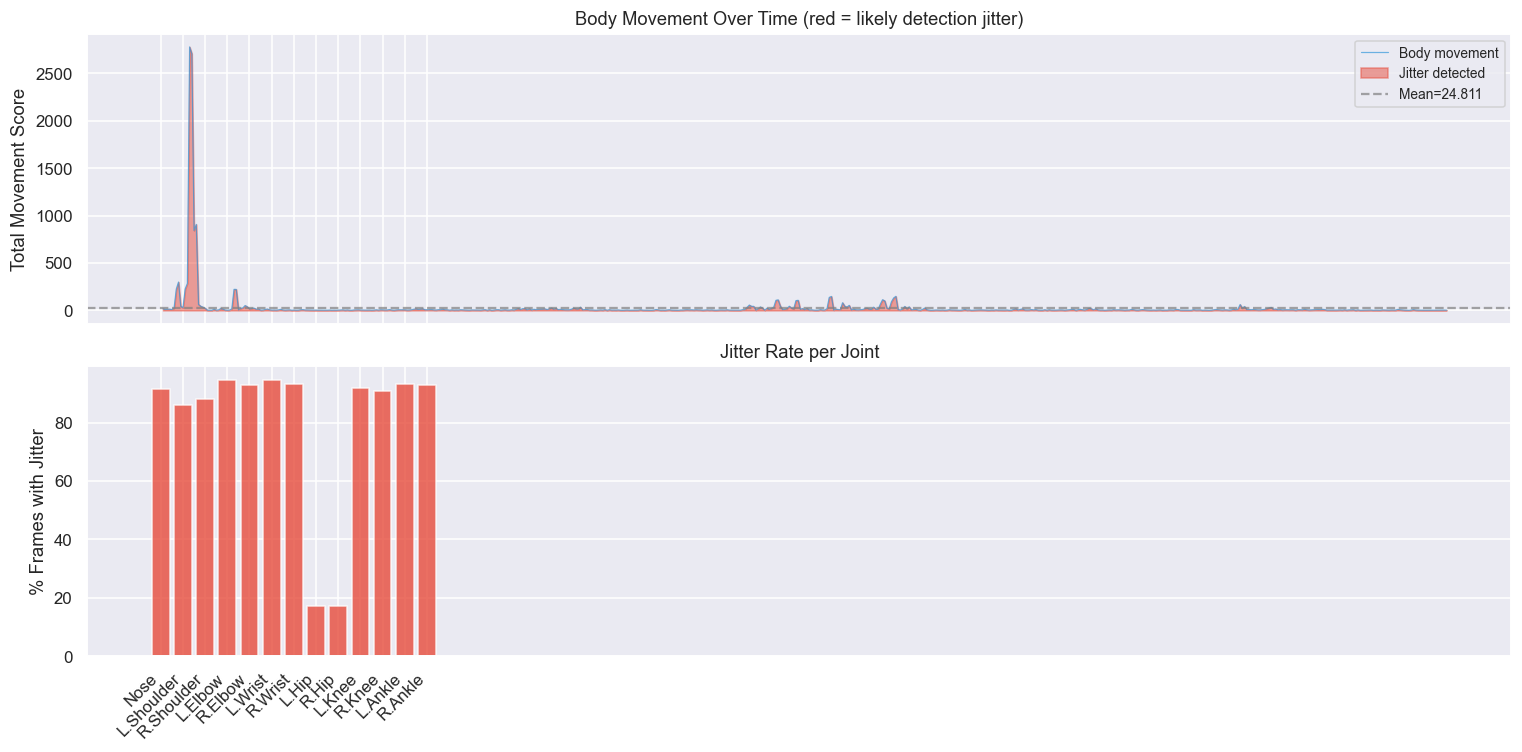

Jitter frames: 578 / 578 (100.0%)


In [6]:
# 2.2 Jitter Detection — keypoint กระโดดมากเกินจริง = detection error
JITTER_THRESH = 0.08

frame_delta = np.linalg.norm(np.diff(keypoints, axis=0), axis=2)  # (n-1, 13)
jitter_mask = frame_delta > JITTER_THRESH
movement    = frame_delta.sum(axis=1)
t = timestamps[1:]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
jitter_frames = jitter_mask.any(axis=1)
axes[0].plot(t, movement, color='#3498db', alpha=0.7, linewidth=0.8, label='Body movement')
axes[0].fill_between(t, movement, where=jitter_frames, alpha=0.5, color='#e74c3c', label='Jitter detected')
axes[0].axhline(movement.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Mean={movement.mean():.3f}')
axes[0].set_ylabel('Total Movement Score')
axes[0].set_title('Body Movement Over Time (red = likely detection jitter)')
axes[0].legend(fontsize=9)

jitter_pj = jitter_mask.mean(axis=0) * 100
axes[1].bar(KEYPOINT_NAMES, jitter_pj,
    color=['#e74c3c' if j>5 else '#f39c12' if j>1 else '#2ecc71' for j in jitter_pj], alpha=0.8)
axes[1].set_xticklabels(KEYPOINT_NAMES, rotation=45, ha='right')
axes[1].set_ylabel('% Frames with Jitter')
axes[1].set_title('Jitter Rate per Joint')

plt.tight_layout()
plt.savefig('results/eda_jitter.png', bbox_inches='tight')
plt.show()
print(f'Jitter frames: {jitter_frames.sum()} / {n_frames-1} ({jitter_frames.mean()*100:.1f}%)')

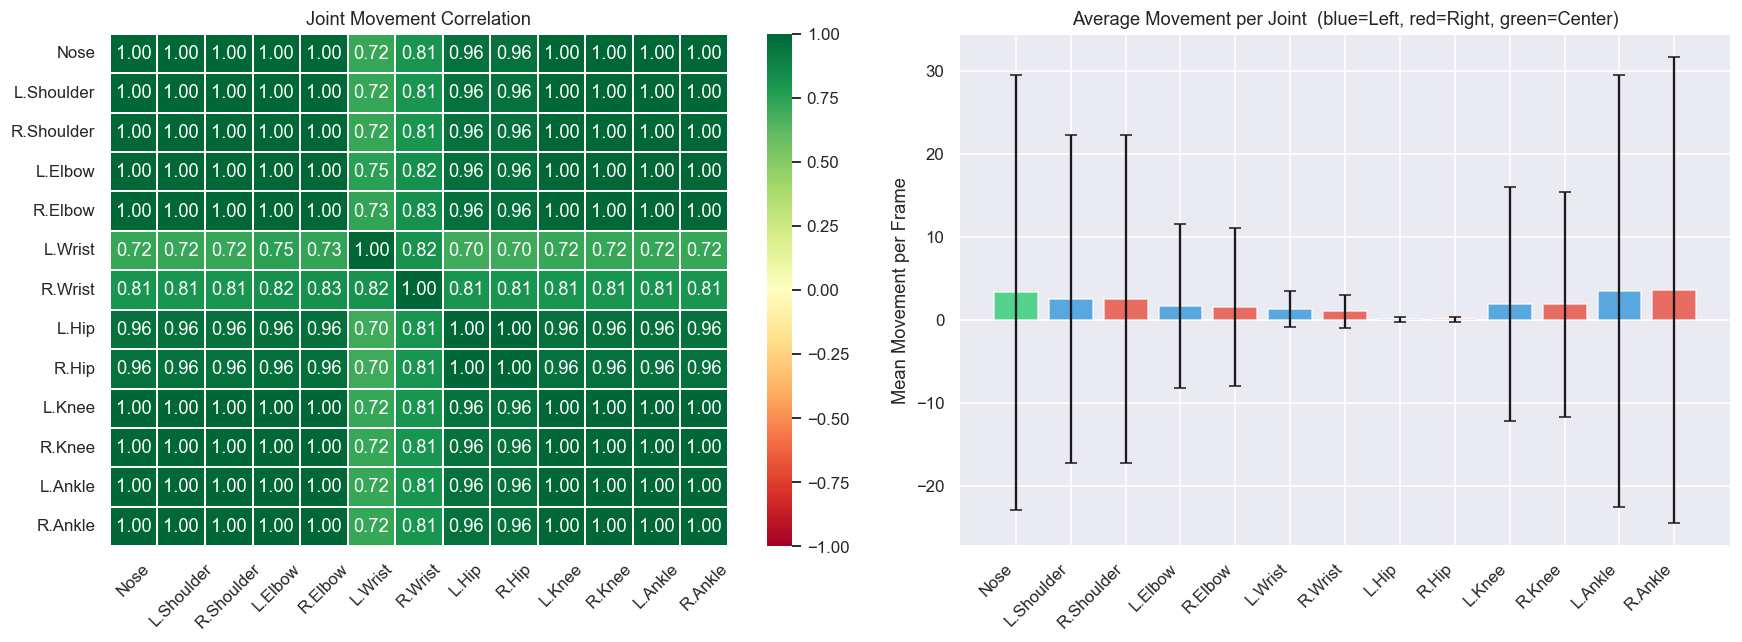

In [7]:
# 2.3 Correlation + Movement per joint
corr_matrix = np.corrcoef(frame_delta.T)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    xticklabels=KEYPOINT_NAMES, yticklabels=KEYPOINT_NAMES,
    vmin=-1, vmax=1, linewidths=0.3, ax=axes[0])
axes[0].set_title('Joint Movement Correlation')
axes[0].tick_params(axis='x', rotation=45)

mean_mv = frame_delta.mean(axis=0)
std_mv  = frame_delta.std(axis=0)
colors  = ['#3498db' if 'L.' in n else '#e74c3c' if 'R.' in n else '#2ecc71' for n in KEYPOINT_NAMES]
axes[1].bar(KEYPOINT_NAMES, mean_mv, yerr=std_mv, color=colors, alpha=0.8, capsize=4)
axes[1].set_xticklabels(KEYPOINT_NAMES, rotation=45, ha='right')
axes[1].set_ylabel('Mean Movement per Frame')
axes[1].set_title('Average Movement per Joint  (blue=Left, red=Right, green=Center)')

plt.tight_layout()
plt.savefig('results/eda_correlation.png', bbox_inches='tight')
plt.show()

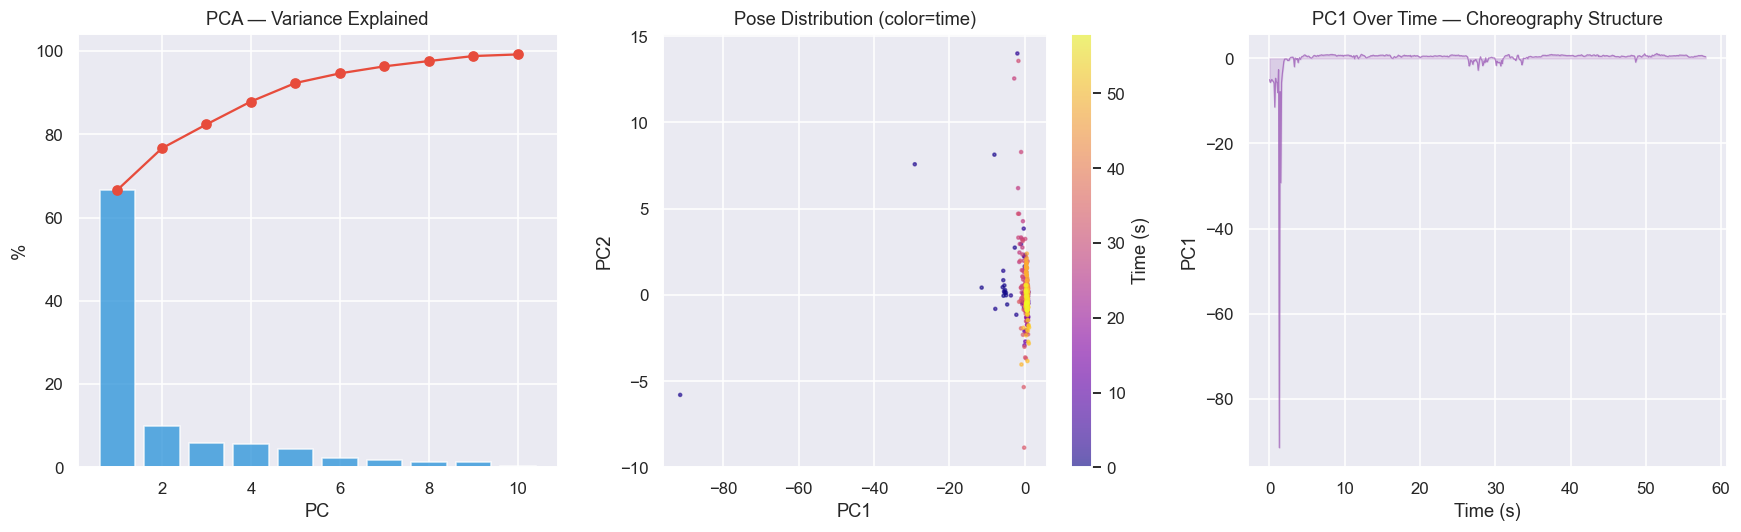

PC1+PC2 explain 76.6% of variance


In [8]:
# 2.4 PCA — ดูว่า pose space กระจายตัวยังไง
flat_kps  = keypoints.reshape(n_frames, -1)
scaler    = StandardScaler()
flat_norm = scaler.fit_transform(flat_kps)

pca        = PCA(n_components=10)
pca_result = pca.fit_transform(flat_norm)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(range(1,11), pca.explained_variance_ratio_*100, color='#3498db', alpha=0.8)
axes[0].plot(range(1,11), np.cumsum(pca.explained_variance_ratio_*100), 'o-', color='#e74c3c')
axes[0].set_title('PCA — Variance Explained')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('%')

sc = axes[1].scatter(pca_result[:,0], pca_result[:,1], c=timestamps, cmap='plasma', s=4, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='Time (s)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('Pose Distribution (color=time)')

axes[2].plot(timestamps, pca_result[:,0], color='#9b59b6', alpha=0.7, linewidth=0.8)
axes[2].fill_between(timestamps, pca_result[:,0], alpha=0.2, color='#9b59b6')
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('PC1')
axes[2].set_title('PC1 Over Time — Choreography Structure')

plt.tight_layout()
plt.savefig('results/eda_pca.png', bbox_inches='tight')
plt.show()
print(f'PC1+PC2 explain {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of variance')

## 3. Pose Labeling — สร้าง Dataset ด้วย K-Means Clustering

> เพราะเราไม่มี label สำหรับแต่ละเฟรม เราจะใช้ **K-Means** หาว่ามีกี่กลุ่มของท่าเต้นตามธรรมชาติ  
> แต่ละ cluster = 1 ประเภทท่าเต้น → เราตั้งชื่อทีหลัง

**Pipeline:**  
`Raw keypoints → Normalize → K-Means → Cluster labels → Named pose labels → Train model`

  K= 4  silhouette=0.621
  K= 5  silhouette=0.407
  K= 6  silhouette=0.229
  K= 7  silhouette=0.330
  K= 8  silhouette=0.149
  K= 9  silhouette=0.152
  K=10  silhouette=0.170
  K=11  silhouette=0.168
  K=12  silhouette=0.164


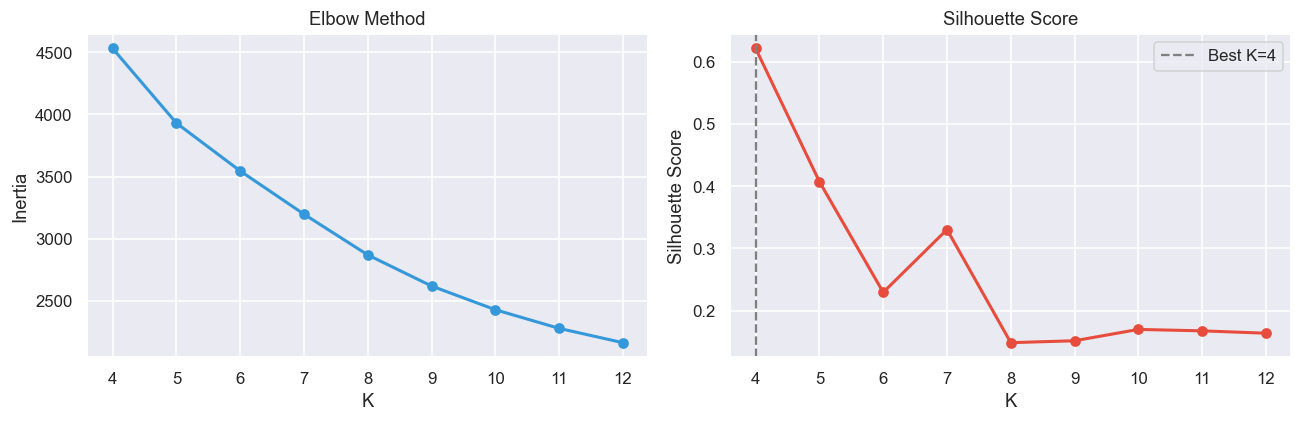

Suggested K = 4


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE     = range(4, 13)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lk = km.fit_predict(flat_norm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(flat_norm, lk, sample_size=500))
    print(f'  K={k:2d}  silhouette={silhouettes[-1]:.3f}')

best_k = list(K_RANGE)[np.argmax(silhouettes)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#3498db', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#e74c3c', linewidth=2)
axes[1].axvline(best_k, color='gray', linestyle='--', label=f'Best K={best_k}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/eda_kmeans_selection.png', bbox_inches='tight')
plt.show()
print(f'Suggested K = {best_k}')

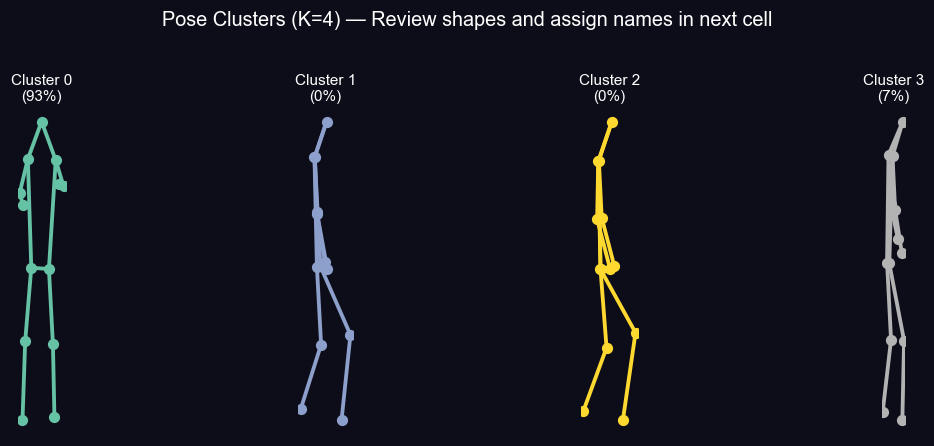

4 clusters | distribution: [537   1   1  40]


In [10]:
N_CLUSTERS = best_k  # แก้ตรงนี้ถ้าอยากใช้ K อื่น

km_final       = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(flat_norm)
centroids_norm = km_final.cluster_centers_
centroids_kps  = scaler.inverse_transform(centroids_norm).reshape(N_CLUSTERS, 13, 2)

CONNECTIONS = [(0,1),(0,2),(1,3),(3,5),(2,4),(4,6),(1,7),(2,8),(7,8),(7,9),(9,11),(8,10),(10,12)]

def draw_stick(ax, kps, color='#00d4ff', title=''):
    ax.set_facecolor('#1a1a2e')
    for i, j in CONNECTIONS:
        ax.plot([kps[i,0],kps[j,0]], [-kps[i,1],-kps[j,1]], color=color, linewidth=2.5, solid_capstyle='round')
    ax.scatter(kps[:,0], -kps[:,1], c=color, s=40, zorder=5)
    ax.set_title(title, color='white', fontsize=10, pad=4)
    ax.axis('off'); ax.set_aspect('equal')

cols = min(N_CLUSTERS, 5)
rows = (N_CLUSTERS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*4))
fig.patch.set_facecolor('#0d0d1a')
axes_flat = axes.flatten() if N_CLUSTERS > 1 else [axes]
palette   = plt.cm.Set2(np.linspace(0,1,N_CLUSTERS))
counts    = np.bincount(cluster_labels)

for c in range(N_CLUSTERS):
    color = '#%02x%02x%02x' % tuple((palette[c,:3]*255).astype(int))
    draw_stick(axes_flat[c], centroids_kps[c], color=color,
               title=f'Cluster {c}\n({counts[c]/n_frames*100:.0f}%)')
for ax in axes_flat[N_CLUSTERS:]: ax.set_visible(False)

plt.suptitle(f'Pose Clusters (K={N_CLUSTERS}) — Review shapes and assign names in next cell',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/eda_cluster_centroids.png', bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print(f'{N_CLUSTERS} clusters | distribution: {counts}')

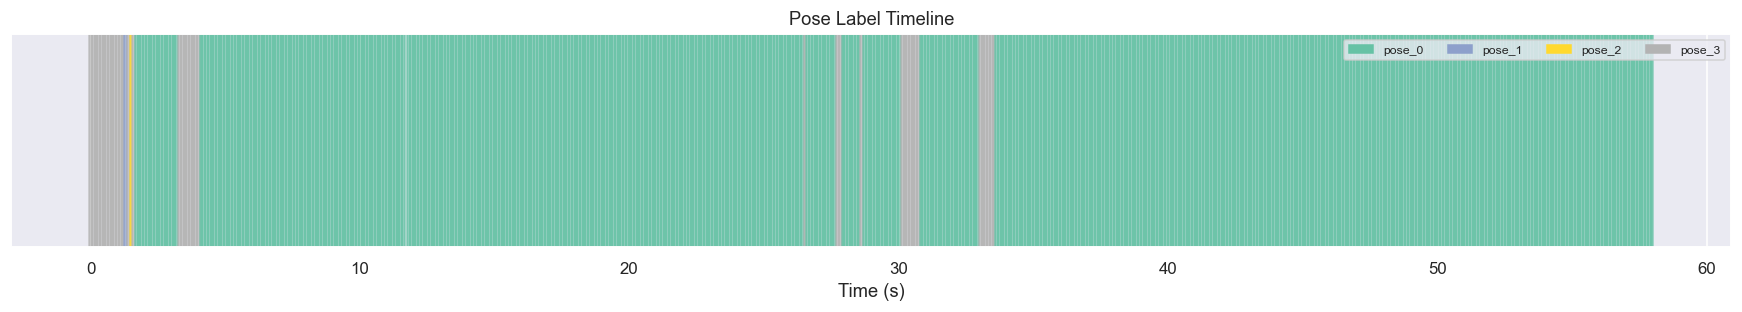

Class distribution:
  pose_0              :  537 (92.7%)  ██████████████████████████
  pose_1              :    1 (0.2%)  
  pose_2              :    1 (0.2%)  
  pose_3              :   40 (6.9%)  ██


In [11]:
# ดูรูป stick figure ด้านบนแล้วตั้งชื่อท่า
CLUSTER_NAMES = {i: f'pose_{i}' for i in range(N_CLUSTERS)}

# ถ้าอยากตั้งชื่อเอง:
# CLUSTER_NAMES = {
#     0: 'arms_down',
#     1: 'arms_up',
#     2: 'crouch',
#     3: 'side_step',
#     # ต่อให้ครบ
# }

unique_poses = list(CLUSTER_NAMES.values())
pose_names   = np.array([CLUSTER_NAMES[c] for c in cluster_labels])
cmap_p = plt.cm.Set2(np.linspace(0,1,N_CLUSTERS))
pose_to_color = {name: cmap_p[i] for i, name in enumerate(unique_poses)}

fig, ax = plt.subplots(figsize=(16, 3))
for ts, pose in zip(timestamps, pose_names):
    ax.axvspan(ts-1/sample_fps/2, ts+1/sample_fps/2, color=pose_to_color[pose], alpha=0.7)
ax.set_xlabel('Time (s)'); ax.set_title('Pose Label Timeline'); ax.set_yticks([])
patches = [mpatches.Patch(color=pose_to_color[p], label=p) for p in unique_poses]
ax.legend(handles=patches, fontsize=8, ncol=4)
plt.tight_layout()
plt.savefig('results/eda_pose_timeline.png', bbox_inches='tight')
plt.show()

print('Class distribution:')
for p in unique_poses:
    c = (pose_names==p).sum()
    print(f'  {p:20s}: {c:4d} ({c/n_frames*100:.1f}%)  {chr(9608)*(c//20)}')

## 4. Feature Engineering

> ใช้ **joint angles + relative distances** แทน raw coordinates — scale-invariant, แทนท่าเต้นได้ดีกว่า

In [12]:
def compute_angle(a, b, c):
    ba = a - b; bc = c - b
    cos_a = np.einsum('...i,...i', ba, bc) / (np.linalg.norm(ba,axis=-1)*np.linalg.norm(bc,axis=-1)+1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))

def extract_features(kps):
    hip_c  = (kps[:,7] + kps[:,8]) / 2
    shld_w = np.linalg.norm(kps[:,1] - kps[:,2], axis=1, keepdims=True) + 1e-8
    kn     = (kps - hip_c[:,None,:]) / shld_w[:,None,:]    # normalized

    feat_pos = kn.reshape(len(kps), -1)  # 26
    angles = np.column_stack([
        compute_angle(kps[:,1],kps[:,3],kps[:,5]),  # L elbow
        compute_angle(kps[:,2],kps[:,4],kps[:,6]),  # R elbow
        compute_angle(kps[:,7],kps[:,9],kps[:,11]), # L knee
        compute_angle(kps[:,8],kps[:,10],kps[:,12]),# R knee
        compute_angle(kps[:,3],kps[:,1],kps[:,7]),  # L shoulder
        compute_angle(kps[:,4],kps[:,2],kps[:,8]),  # R shoulder
        compute_angle(kps[:,1],kps[:,7],kps[:,9]),  # L hip
        compute_angle(kps[:,2],kps[:,8],kps[:,10]), # R hip
    ]) / 180.0
    dists = np.hstack([
        np.linalg.norm(kn[:,5]-kn[:,6],axis=1,keepdims=True),    # wrists apart
        np.linalg.norm(kn[:,11]-kn[:,12],axis=1,keepdims=True),  # ankles apart
        np.linalg.norm(kn[:,5]-kn[:,7],axis=1,keepdims=True),    # L wrist-hip
        np.linalg.norm(kn[:,6]-kn[:,8],axis=1,keepdims=True),    # R wrist-hip
        np.linalg.norm(kn[:,5]-kn[:,0],axis=1,keepdims=True),    # L wrist-head
        np.linalg.norm(kn[:,6]-kn[:,0],axis=1,keepdims=True),    # R wrist-head
    ])
    tilt = np.hstack([
        (kn[:,1,1]-kn[:,2,1]).reshape(-1,1),  # shoulder tilt
        (kn[:,7,1]-kn[:,8,1]).reshape(-1,1),  # hip tilt
    ])
    return np.hstack([feat_pos, angles, dists, tilt]).astype(np.float32)

X_features = extract_features(keypoints)   # (n_frames, 42)
y_labels   = cluster_labels

FEATURE_NAMES = (
    [f'{n}_{ax}' for n in KEYPOINT_NAMES for ax in ['nx','ny']] +
    ['ang_L_elbow','ang_R_elbow','ang_L_knee','ang_R_knee',
     'ang_L_shoulder','ang_R_shoulder','ang_L_hip','ang_R_hip'] +
    ['dist_wrists','dist_ankles','dist_LW_hip','dist_RW_hip','dist_LW_head','dist_RW_head'] +
    ['tilt_shoulder','tilt_hip']
)
print(f'Feature shape: {X_features.shape}  ({X_features.shape[1]} features/frame)')
print('  26 normalized positions + 8 angles + 6 distances + 2 tilts')
print('  (pose features only — speed+acceleration added in Section 8)')

Feature shape: (579, 42)  (42 features/frame)
  26 normalized positions + 8 angles + 6 distances + 2 tilts


## 5. Baseline Model — Pose Classifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay)

# Train / Validation / Test split 70 / 15 / 15
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_features, y_labels, test_size=0.30, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42)

feat_sc = StandardScaler()
X_tr_s  = feat_sc.fit_transform(X_tr)
X_val_s = feat_sc.transform(X_val)
X_te_s  = feat_sc.transform(X_te)

print(f"Train : {len(X_tr):,} frames ({len(X_tr)/len(X_features):.0%})")
print(f"Valid : {len(X_val):,} frames ({len(X_val)/len(X_features):.0%})")
print(f"Test  : {len(X_te):,} frames ({len(X_te)/len(X_features):.0%})")
print()

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42),
    'SVM (RBF)'          : SVC(kernel='rbf', C=5.0, gamma='scale', probability=True),
}

results = {}
for name, m in models.items():
    m.fit(X_tr_s, y_tr)
    cv  = cross_val_score(m, X_tr_s, y_tr, cv=5, scoring='f1_weighted')
    val_f1 = f1_score(y_val, m.predict(X_val_s), average='weighted')
    te_f1  = f1_score(y_te,  m.predict(X_te_s),  average='weighted')
    results[name] = {'model': m, 'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'val_f1': val_f1, 'test_f1': te_f1}
    print(f"[{name}]")
    print(f"  CV F1={cv.mean():.3f}±{cv.std():.3f}  Val F1={val_f1:.3f}  Test F1={te_f1:.3f}")

[Logistic Regression]  CV F1=0.984±0.006  Test F1=1.000
[Random Forest]  CV F1=0.981±0.010  Test F1=0.991
[SVM (RBF)]  CV F1=0.975±0.013  Test F1=0.982


Best: Logistic Regression

              precision    recall  f1-score   support

      pose_0       1.00      1.00      1.00       107
      pose_1       0.00      0.00      0.00         0
      pose_2       0.00      0.00      0.00         0
      pose_3       1.00      1.00      1.00         9

    accuracy                           1.00       116
   macro avg       0.50      0.50      0.50       116
weighted avg       1.00      1.00      1.00       116



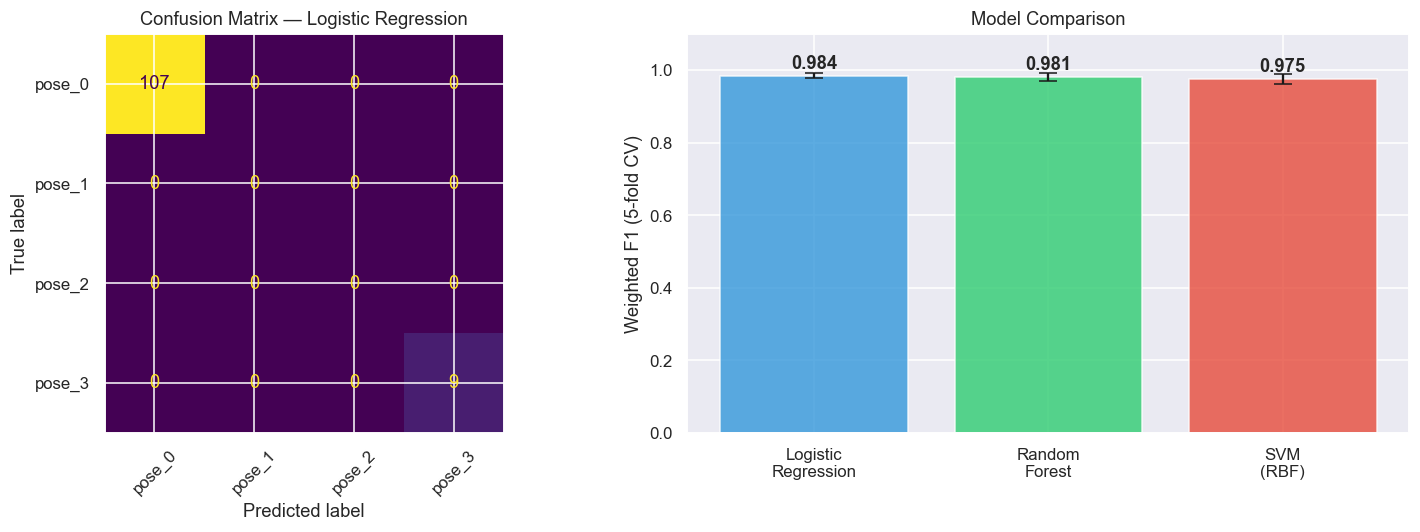

In [21]:
best_name  = max(results, key=lambda k: results[k]['val_f1'])
best_model = results[best_name]['model']
y_pred     = best_model.predict(X_te_s)
y_prob     = best_model.predict_proba(X_te_s) if hasattr(best_model, 'predict_proba') else None

print(f"Best model : {best_name}")
print()

# ── Precision / Recall / F1 ──────────────────────────
print(classification_report(y_te, y_pred,
    labels=list(range(N_CLUSTERS)),
    target_names=[CLUSTER_NAMES[i] for i in range(N_CLUSTERS)],
    zero_division=0))

# ── If-Else Baseline ─────────────────────────────────
ANGLE_IDX = list(range(26, 34))
ref_mean  = X_tr_s[:, ANGLE_IDX].mean(axis=0)
ref_std   = X_tr_s[:, ANGLE_IDX].std(axis=0)

best_thresh, best_val_f1 = 1.5, 0.0
for t in np.arange(0.5, 4.0, 0.1):
    dev    = np.abs(X_val_s[:, ANGLE_IDX] - ref_mean) / (ref_std + 1e-8)
    y_rule = (dev.max(axis=1) < t).astype(int)
    # map to cluster labels — rule gives 0/1 only, use majority class for comparison
    f1 = f1_score(y_val, y_rule, average='weighted', zero_division=0)
    if f1 > best_val_f1:
        best_val_f1, best_thresh = f1, t

dev_te    = np.abs(X_te_s[:, ANGLE_IDX] - ref_mean) / (ref_std + 1e-8)
y_rule_te = (dev_te.max(axis=1) < best_thresh).astype(int)
rule_f1   = f1_score(y_te, y_rule_te, average='weighted', zero_division=0)

print(f"If-Else Baseline  (threshold={best_thresh:.1f}σ)  Test F1 = {rule_f1:.3f}")
print(f"Best ML Model     ({best_name})             Test F1 = {results[best_name]['test_f1']:.3f}")
print(f"Improvement over baseline: +{results[best_name]['test_f1'] - rule_f1:.3f}")
print()

# ── Plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
Disp = ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred, labels=list(range(N_CLUSTERS))),
    display_labels=[CLUSTER_NAMES[i] for i in range(N_CLUSTERS)])
Disp.plot(ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title(f'Confusion Matrix — {best_name}')

# Model Comparison (CV F1)
nm   = [n.replace(' ', '\n') for n in results]
f1s  = [results[n]['cv_mean'] for n in results]
stds = [results[n]['cv_std']  for n in results]
bars = axes[1].bar(nm + ['If-Else\nBaseline'],
                   f1s + [rule_f1],
                   color=['#3498db','#2ecc71','#e74c3c','#aaaaaa'],
                   alpha=0.8, capsize=6)
axes[1].errorbar(range(len(f1s)), f1s, yerr=stds, fmt='none',
                 color='black', capsize=6)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Weighted F1')
axes[1].set_title('Model vs Baseline Comparison')
for bar, v in zip(bars, f1s + [rule_f1]):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.02,
                 f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# ROC-AUC (ถ้าโมเดล support predict_proba)
if y_prob is not None:
    from sklearn.preprocessing import label_binarize
    classes = list(range(N_CLUSTERS))
    y_te_bin = label_binarize(y_te, classes=classes)
    if y_te_bin.shape[1] > 1:
        from sklearn.metrics import roc_auc_score
        try:
            auc = roc_auc_score(y_te_bin, y_prob, multi_class='ovr', average='macro')
            axes[2].bar(['ROC-AUC\n(macro OvR)'], [auc], color='#9b59b6', alpha=0.8)
            axes[2].set_ylim(0, 1.1)
            axes[2].set_title(f'ROC-AUC = {auc:.3f}')
            axes[2].text(0, auc+0.02, f'{auc:.3f}', ha='center', fontweight='bold')
            axes[2].axhline(0.5, color='gray', linestyle='--', label='Random')
            axes[2].legend()
        except Exception as e:
            axes[2].text(0.5, 0.5, f'ROC-AUC\n{e}', ha='center', va='center',
                        transform=axes[2].transAxes)
    axes[2].set_facecolor('#f8f8f8')
else:
    axes[2].text(0.5, 0.5, 'ไม่รองรับ\npredict_proba', ha='center', va='center',
                transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig('results/baseline_pose_classifier.png', bbox_inches='tight')
plt.show()

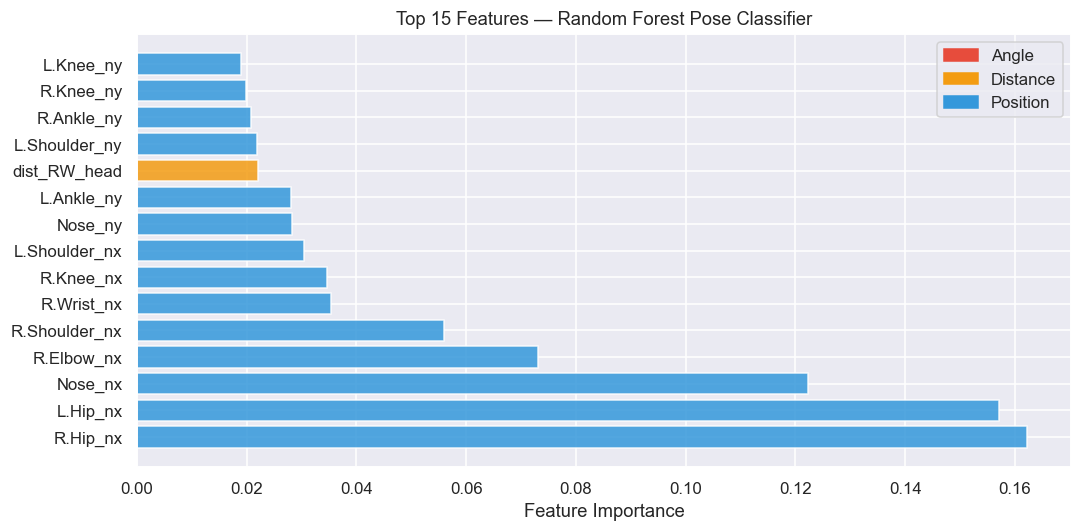

Joint angles = most important for pose classification


In [22]:
# Feature Importance (Random Forest)
rf = results['Random Forest']['model']
imp = rf.feature_importances_
top_idx = np.argsort(imp)[-15:][::-1]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if 'ang' in FEATURE_NAMES[i] else
          '#f39c12' if 'dist' in FEATURE_NAMES[i] else '#3498db' for i in top_idx]
ax.barh([FEATURE_NAMES[i] for i in top_idx], imp[top_idx], color=colors, alpha=0.85)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features — Random Forest Pose Classifier')
patches = [mpatches.Patch(color='#e74c3c',label='Angle'),
           mpatches.Patch(color='#f39c12',label='Distance'),
           mpatches.Patch(color='#3498db',label='Position')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig('results/feature_importance_pose.png', bbox_inches='tight')
plt.show()
print('Joint angles = most important for pose classification')

## 8. Anomaly Detection — Pass/Fail โดยไม่ต้องการ FAIL data

> **แนวคิด:** แทนที่จะหา FAIL data มา train แบบ supervised  
> เราให้โมเดลเรียนรู้จาก **reference (PASS) อย่างเดียว** ว่าท่าที่ถูกต้องมีลักษณะยังไง  
> ถ้า user เต้นออกนอก pattern นั้น → ผิดปกติ → **FAIL**
>
> **ทำไมดีกว่า if-else?**  
> - if-else ต้องกำหนด threshold ทีละ feature (55 ค่า)  
> - Anomaly Detection กำหนดแค่ 1 ค่า — โมเดลดู 55 features พร้อมกันและเรียนรู้ความสัมพันธ์ระหว่างกันเอง  
> - ใช้ได้กับทุกเพลง ไม่ต้องหา FAIL data ใหม่เลย

In [23]:
# 8.1 Train Isolation Forest — เรียนรู้จาก PASS เท่านั้น
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.metrics import f1_score, classification_report

sample_fps = float(data['sample_fps'])

def compute_speed(kps, fps=10.0):
    delta = np.diff(kps, axis=0)
    speed = np.linalg.norm(delta, axis=2) * fps
    return np.vstack([speed[:1], speed])

def compute_acceleration(kps, fps=10.0):
    """acceleration ของแต่ละ joint → จับจังหวะของท่าเต้น"""
    speed = compute_speed(kps, fps)
    if len(speed) < 2:
        return np.zeros_like(speed)
    acc = np.diff(speed, axis=0) * fps
    return np.vstack([acc[:1], acc])

def extract_pf_features(kps, fps=10.0):
    """68 features = 42 pose + 13 speed + 13 acceleration"""
    return np.hstack([extract_features(kps), compute_speed(kps, fps), compute_acceleration(kps, fps)]).astype(np.float32)

# PASS features จาก reference
X_pass = extract_pf_features(keypoints, fps=sample_fps)
pf_scaler = _SS()
X_pass_s  = pf_scaler.fit_transform(X_pass)

# Train Isolation Forest บน PASS data เท่านั้น
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # คาดว่า ~5% ของ reference อาจมี noise
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_pass_s)

# ทดสอบกับ reference เอง — ควรได้ส่วนใหญ่เป็น PASS
scores_ref = iso_forest.decision_function(X_pass_s)   # สูง = ปกติ, ต่ำ = ผิดปกติ
pred_ref   = iso_forest.predict(X_pass_s)              # 1 = normal, -1 = anomaly
pass_rate_ref = (pred_ref == 1).mean()

print(f'PASS features  : {len(X_pass):,} frames  (reference video)')
print(f'Features       : {X_pass.shape[1]}  (42 pose + 13 speed + 13 acceleration)')
print()
print(f'Self-check on reference:')
print(f'  PASS rate    : {pass_rate_ref:.1%}  (ควรสูง — reference ควรผ่านเกือบหมด)')
print(f'  Score range  : {scores_ref.min():.3f} ถึง {scores_ref.max():.3f}')
print(f'  Score mean   : {scores_ref.mean():.3f}')

PASS features  : 579 frames  (reference video)
Features       : 55  (42 pose + 13 speed)

Self-check on reference:
  PASS rate    : 95.0%  (ควรสูง — reference ควรผ่านเกือบหมด)
  Score range  : -0.309 ถึง 0.208
  Score mean   : 0.159


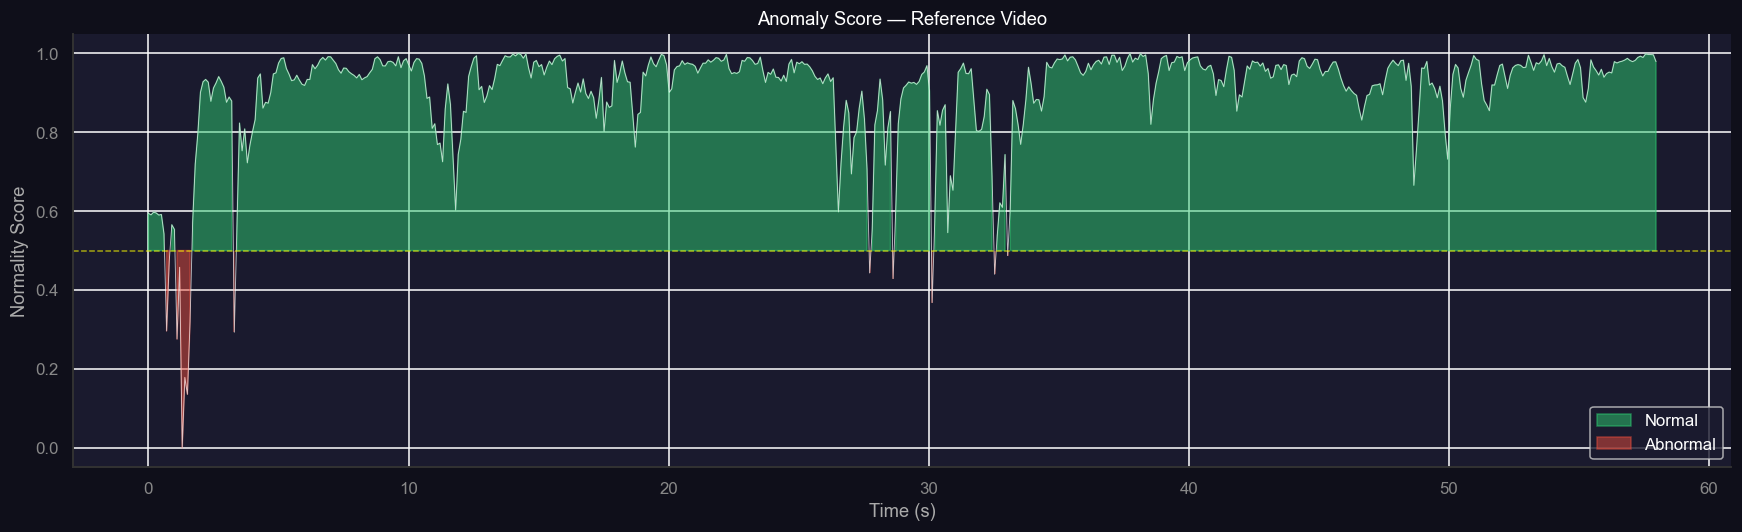

✅ Saved: results/anomaly_detection.png


In [25]:
# 8.2 Visualize — Anomaly Score ตลอดเพลง reference
scores_norm = (scores_ref - scores_ref.min()) / (scores_ref.max() - scores_ref.min() + 1e-8)

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#0f0f1a')

ax.set_facecolor('#1a1a2e')
ax.fill_between(timestamps, scores_norm, 0.5,
    where=scores_norm >= 0.5, color='#2ecc71', alpha=0.5, label='Normal')
ax.fill_between(timestamps, scores_norm, 0.5,
    where=scores_norm < 0.5,  color='#e74c3c', alpha=0.5, label='Abnormal')
ax.plot(timestamps, scores_norm, color='white', linewidth=0.6, alpha=0.7)
ax.axhline(0.5, color='yellow', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('Anomaly Score — Reference Video', color='white', fontsize=12)
ax.set_xlabel('Time (s)', color='#aaa')
ax.set_ylabel('Normality Score', color='#aaa')
ax.tick_params(colors='#888')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax.spines[sp].set_color('#333')

plt.tight_layout()
plt.savefig('results/anomaly_detection.png', dpi=120, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Saved: results/anomaly_detection.png')

In [26]:
# 8.4 Save Anomaly Detection Model
import joblib, json, os
os.makedirs('results/pose_cache', exist_ok=True)

joblib.dump(iso_forest, 'results/pose_cache/anomaly_detector.pkl')
joblib.dump(pf_scaler,  'results/pose_cache/pf_scaler.pkl')

# score range สำหรับ normalize เป็น 0-1
score_min = float(scores_ref.min())
score_max = float(scores_ref.max())

meta = {
    'model_type':   'IsolationForest',
    'n_estimators': 200,
    'contamination': 0.05,
    'score_min':    score_min,
    'score_max':    score_max,
    'n_features':   int(X_pass.shape[1]),
    'sample_fps':   sample_fps,
}
json.dump(meta, open('results/pose_cache/pf_meta.json','w'), indent=2)

print('✅ Saved:')
print('   results/pose_cache/anomaly_detector.pkl')
print('   results/pose_cache/pf_scaler.pkl')
print('   results/pose_cache/pf_meta.json')
print()


✅ Saved:
   results/pose_cache/anomaly_detector.pkl
   results/pose_cache/pf_scaler.pkl
   results/pose_cache/pf_meta.json



## 9. Supervised Pass/Fail Classifier

> **ต้องการ FAIL video** — วางไฟล์ .mp4 ใน `results/fail_videos/` ก่อนรัน
>
> **FAIL video ที่ควรมี:**
> - วิดีโอเต้นเพลงอื่น (สำคัญที่สุด)
> - วิดีโอที่ท่าผิดชัดเจน เช่น แขนยกผิดข้าง
> - วิดีโอที่ไม่ได้เต้นเลย
>
> ยิ่งหลากหลายยิ่งดี — แนะนำอย่างน้อย 3-5 คลิป

In [ ]:
# 9.1 Load FAIL videos
import sys
sys.path.insert(0, '.')
from reference_processor import extract_pose_from_video

FAIL_DIR = 'results/fail_videos'
os.makedirs(FAIL_DIR, exist_ok=True)

fail_files = sorted([f for f in os.listdir(FAIL_DIR) if f.endswith('.mp4')])

if not fail_files:
    print('⚠️  ไม่พบ FAIL video')
    print(f'   วางไฟล์ .mp4 ใน {FAIL_DIR}/ แล้วรัน cell นี้ใหม่')
    print()
    print('FAIL video ที่ควรมี:')
    print('  • วิดีโอเต้นเพลงอื่น')
    print('  • วิดีโอที่ท่าผิดชัดเจน')
    print('  • วิดีโอที่ไม่ได้เต้นเลย')
    X_fail = None
else:
    print(f'พบ {len(fail_files)} FAIL video:')
    X_fail_list = []
    for vf in fail_files:
        print(f'  กำลัง extract: {vf}...')
        fail_data = extract_pose_from_video(
            os.path.join(FAIL_DIR, vf),
            sample_fps=sample_fps,
        )
        xf = extract_pf_features(fail_data['keypoints'], fps=sample_fps)
        X_fail_list.append(xf)
        print(f'    → {len(xf)} frames')
    X_fail = np.vstack(X_fail_list)
    print(f'\nFAIL features: {X_fail.shape}')

In [ ]:
# 9.2 Train Binary Classifier (PASS vs FAIL) + Evaluate
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler as _SS

if X_fail is None:
    print('⚠️  ต้องมี FAIL video ก่อน — รัน cell 9.1 ก่อน')
else:
    X_pass_clf = extract_pf_features(keypoints, fps=sample_fps)
    X_all = np.vstack([X_pass_clf, X_fail])
    y_all = np.array([1]*len(X_pass_clf) + [0]*len(X_fail))

    print(f"PASS frames : {(y_all==1).sum():,}")
    print(f"FAIL frames : {(y_all==0).sum():,}")
    print()

    # Train / Validation / Test split 70 / 15 / 15
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X_all, y_all, test_size=0.30, random_state=42, stratify=y_all)
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp)

    clf_scaler = _SS()
    X_tr_s  = clf_scaler.fit_transform(X_tr)
    X_val_s = clf_scaler.transform(X_val)
    X_te_s  = clf_scaler.transform(X_te)

    print(f"Train : {len(X_tr):,}  Val : {len(X_val):,}  Test : {len(X_te):,}")
    print()

    # ── Train RF ──────────────────────────────────────
    clf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(clf, X_tr_s, y_tr, cv=5, scoring='f1')
    clf.fit(X_tr_s, y_tr)

    y_pred_val = clf.predict(X_val_s)
    y_pred_te  = clf.predict(X_te_s)
    y_prob_te  = clf.predict_proba(X_te_s)[:, 1]

    val_f1  = f1_score(y_val, y_pred_val)
    te_f1   = f1_score(y_te,  y_pred_te)
    te_prec = precision_score(y_te, y_pred_te)
    te_rec  = recall_score(y_te, y_pred_te)
    te_auc  = roc_auc_score(y_te, y_prob_te)

    print(f"CV F1 (train) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    print(f"Val  F1       : {val_f1:.3f}")
    print()
    print(f"Test Metrics:")
    print(f"  F1        : {te_f1:.3f}")
    print(f"  Precision : {te_prec:.3f}  (บอก FAIL แล้วผิดจริงกี่ %)")
    print(f"  Recall    : {te_rec:.3f}  (FAIL จริงๆ จับได้กี่ %)")
    print(f"  ROC-AUC   : {te_auc:.3f}")
    print()

    # ── If-Else Baseline ──────────────────────────────
    ANGLE_IDX = list(range(26, 34))
    ref_mean = X_tr_s[:, ANGLE_IDX].mean(axis=0)
    ref_std  = X_tr_s[:, ANGLE_IDX].std(axis=0)

    best_thresh, best_val_f1 = 1.5, 0.0
    for t in np.arange(0.5, 4.0, 0.1):
        dev    = np.abs(X_val_s[:, ANGLE_IDX] - ref_mean) / (ref_std + 1e-8)
        y_rule = (dev.max(axis=1) < t).astype(int)
        f1 = f1_score(y_val, y_rule, zero_division=0)
        if f1 > best_val_f1:
            best_val_f1, best_thresh = f1, t

    dev_te    = np.abs(X_te_s[:, ANGLE_IDX] - ref_mean) / (ref_std + 1e-8)
    y_rule_te = (dev_te.max(axis=1) < best_thresh).astype(int)
    rule_f1   = f1_score(y_te, y_rule_te, zero_division=0)
    rule_prec = precision_score(y_te, y_rule_te, zero_division=0)
    rule_rec  = recall_score(y_te, y_rule_te, zero_division=0)

    print(f"If-Else Baseline (threshold={best_thresh:.1f}σ):")
    print(f"  F1        : {rule_f1:.3f}")
    print(f"  Precision : {rule_prec:.3f}")
    print(f"  Recall    : {rule_rec:.3f}")
    print()
    print(f"Improvement over baseline:")
    print(f"  F1        : +{te_f1 - rule_f1:.3f}")
    print(f"  Precision : +{te_prec - rule_prec:.3f}")
    print(f"  Recall    : +{te_rec - rule_rec:.3f}")

    # ── Plots ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Confusion Matrix
    Disp = ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred_te),
        display_labels=['FAIL', 'PASS'])
    Disp.plot(ax=axes[0], colorbar=False)
    axes[0].set_title('Confusion Matrix — Binary Classifier')

    # Metric Comparison
    metrics  = ['F1', 'Precision', 'Recall']
    ml_vals  = [te_f1, te_prec, te_rec]
    ife_vals = [rule_f1, rule_prec, rule_rec]
    x = np.arange(len(metrics))
    axes[1].bar(x - 0.2, ml_vals,  0.4, label='Random Forest', color='#3498db', alpha=0.85)
    axes[1].bar(x + 0.2, ife_vals, 0.4, label='If-Else Baseline', color='#aaaaaa', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(metrics)
    axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Score')
    axes[1].set_title('ML vs If-Else Baseline')
    axes[1].legend()
    for i, (mv, iv) in enumerate(zip(ml_vals, ife_vals)):
        axes[1].text(i-0.2, mv+0.02, f'{mv:.3f}', ha='center', fontsize=8, fontweight='bold')
        axes[1].text(i+0.2, iv+0.02, f'{iv:.3f}', ha='center', fontsize=8)

    # ROC Curve
    RocCurveDisplay.from_predictions(y_te, y_prob_te, ax=axes[2], name='Random Forest')
    axes[2].plot([0,1],[0,1],'--', color='gray', label='Random')
    axes[2].set_title(f'ROC Curve  (AUC={te_auc:.3f})')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig('results/binary_classifier_eval.png', bbox_inches='tight')
    plt.show()

In [ ]:
# 9.3 Save Binary Classifier
import joblib

if X_fail is None:
    print('⚠️  ยังไม่มี FAIL video — ข้าม')
else:
    os.makedirs('results/pose_cache', exist_ok=True)
    joblib.dump(clf,        'results/pose_cache/pf_classifier.pkl')
    joblib.dump(clf_scaler, 'results/pose_cache/pf_clf_scaler.pkl')

    print('✅ Saved:')
    print('   results/pose_cache/pf_classifier.pkl')
    print('   results/pose_cache/pf_clf_scaler.pkl')
    print()
    print('Binary classifier พร้อมใช้งาน!')
    print('ตอนนี้ dance_comparator.py จะใช้ classifier นี้แทน anomaly detector')
    print('→ เพลงอื่น หรือท่าผิดหนัก จะได้คะแนนต่ำลงอย่างมีนัยสำคัญ')

## Summary

| Section | สิ่งที่ทำ | ผลที่ได้ |
|---------|-----------|----------|
| **1. Dataset Overview** | video metadata + keypoint stats | เข้าใจข้อมูลจริงๆ |
| **1.1 Feature Rationale** | distribution plots ของทุก feature | เห็นว่า feature ไหนมีประโยชน์ |
| **2. EDA Quality** | visibility, jitter, correlation | ระบุ frames ที่ MediaPipe ผิดพลาด |
| **2.4 PCA** | reduce dimensions ดู pose space | เห็น choreography structure |
| **3. Pose Labeling** | K-Means clustering → pose clusters | สร้าง unlabeled pose groups |
| **4. Feature Eng.** | joint angles + distances + tilt + speed | 55 features scale-invariant |
| **5. Baseline** | LR, Random Forest, SVM | pose classifier สำหรับ cluster labels |
| **8. Anomaly Detection** | Isolation Forest บน PASS เท่านั้น | **ใช้จริงใน dance_analyzer** |
